# ICASN

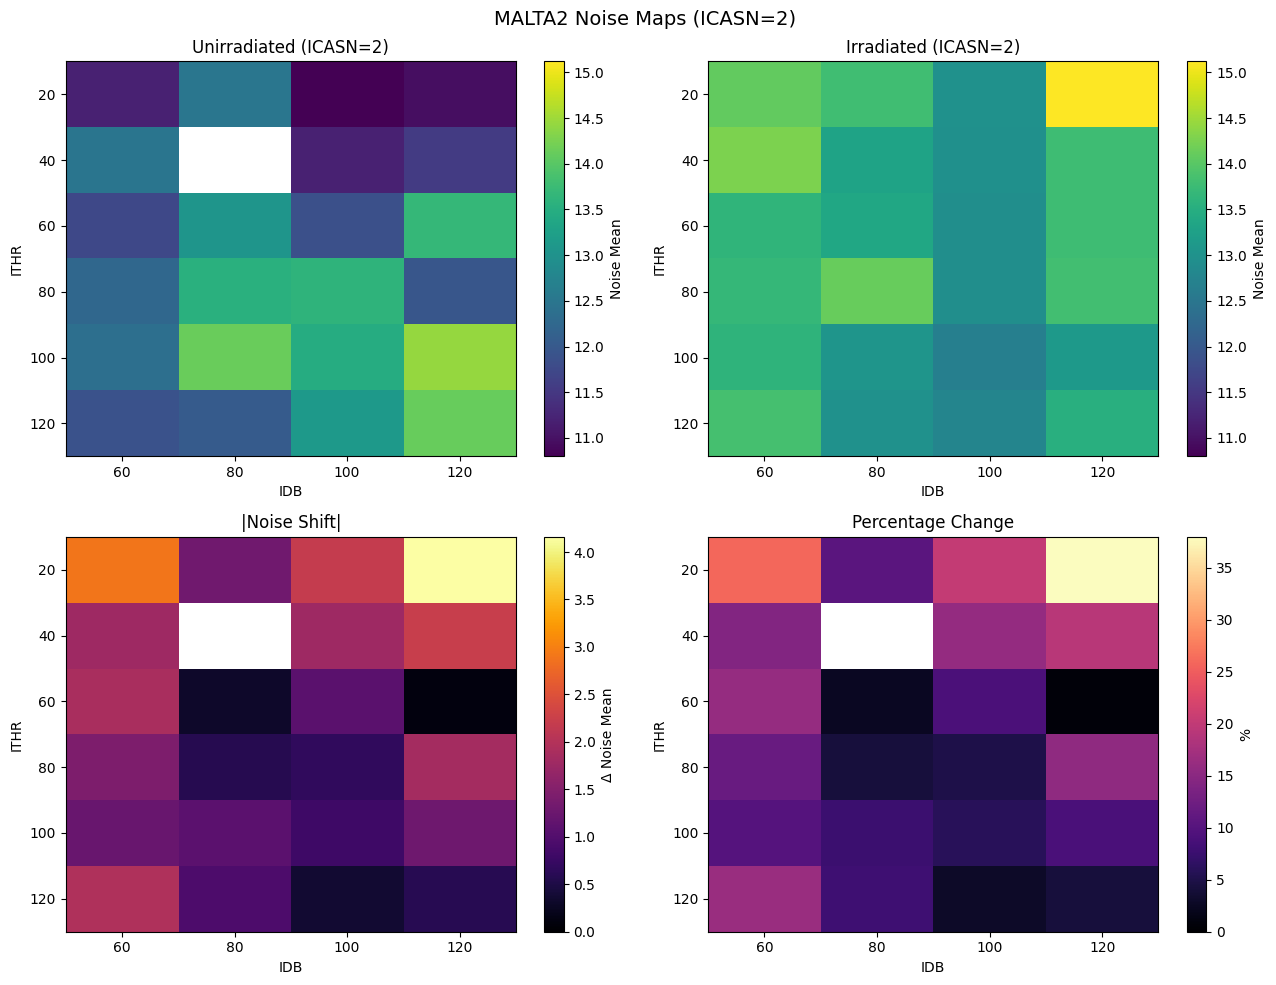

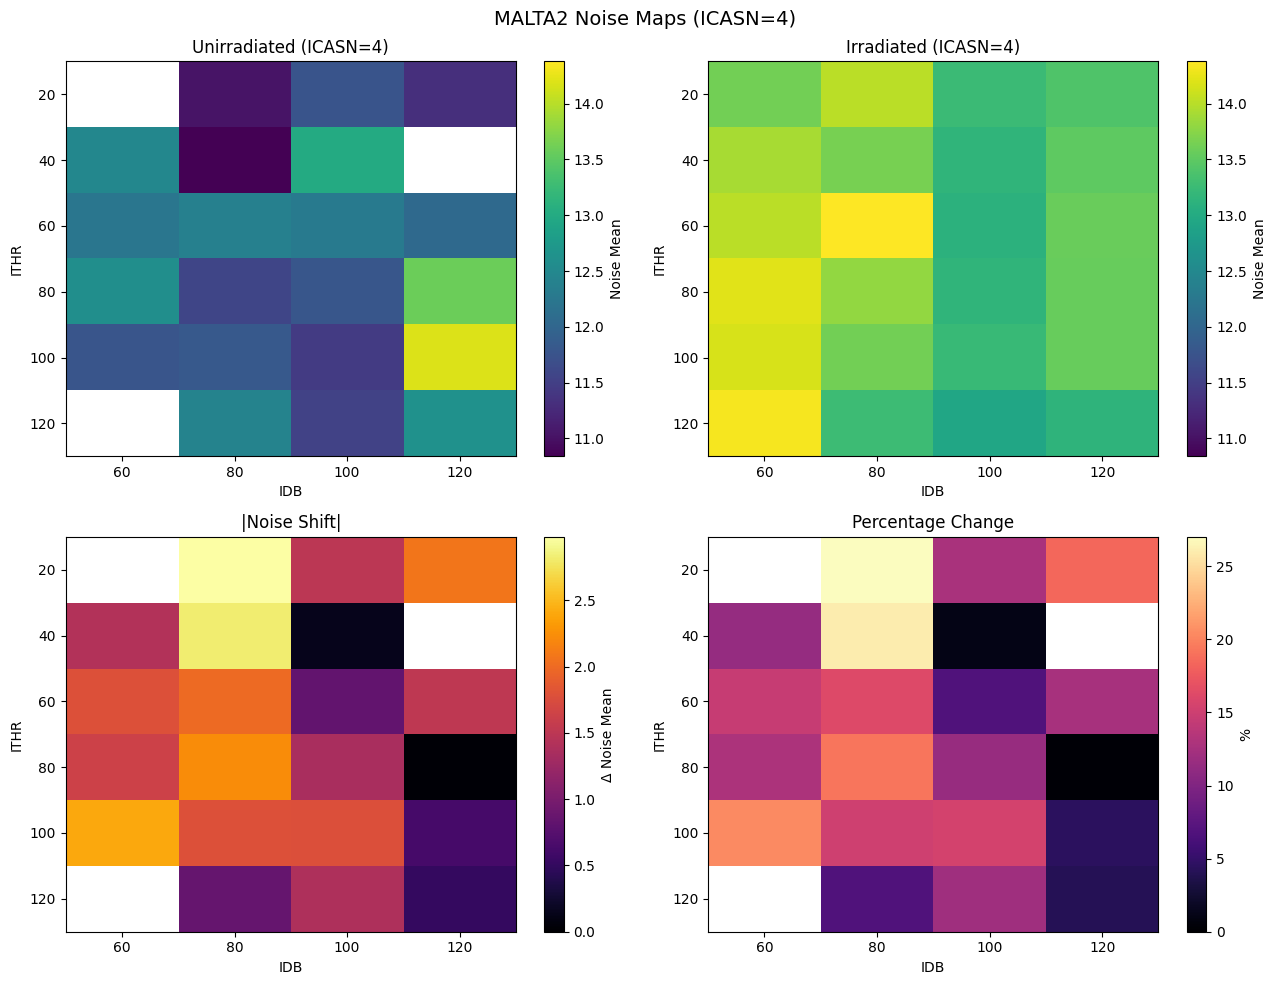

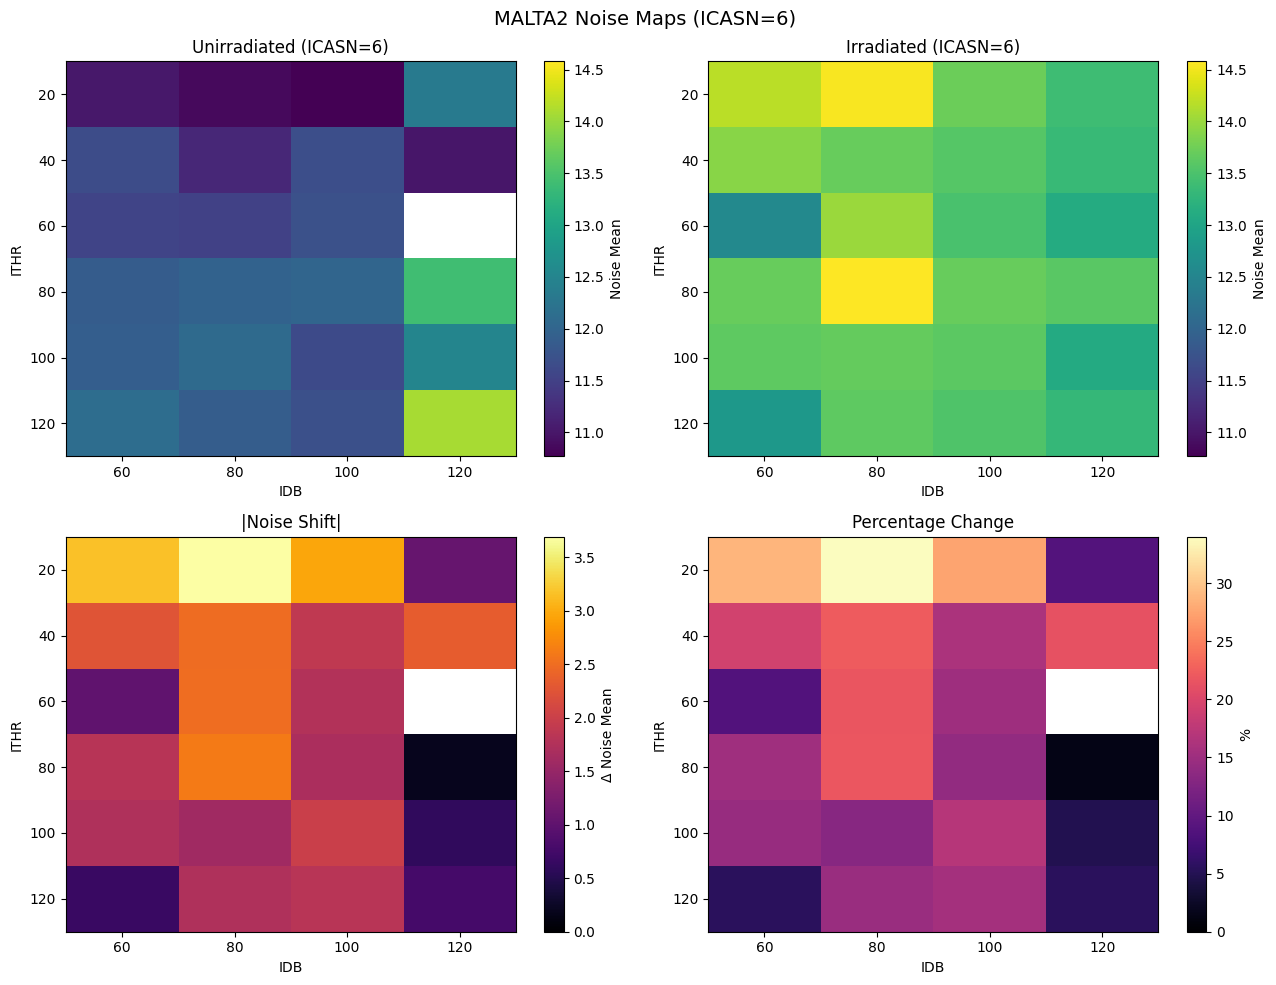

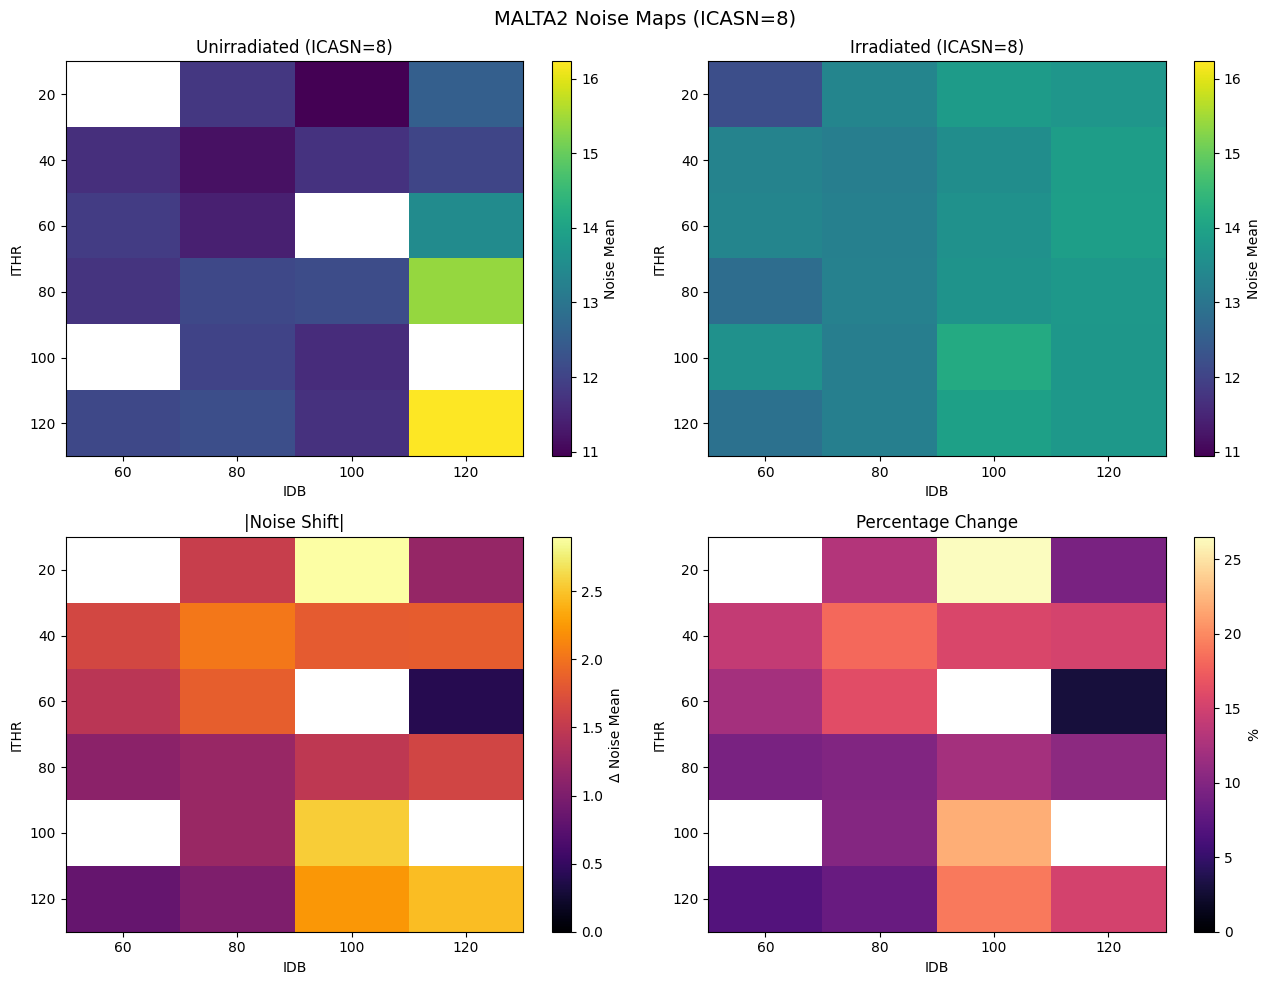

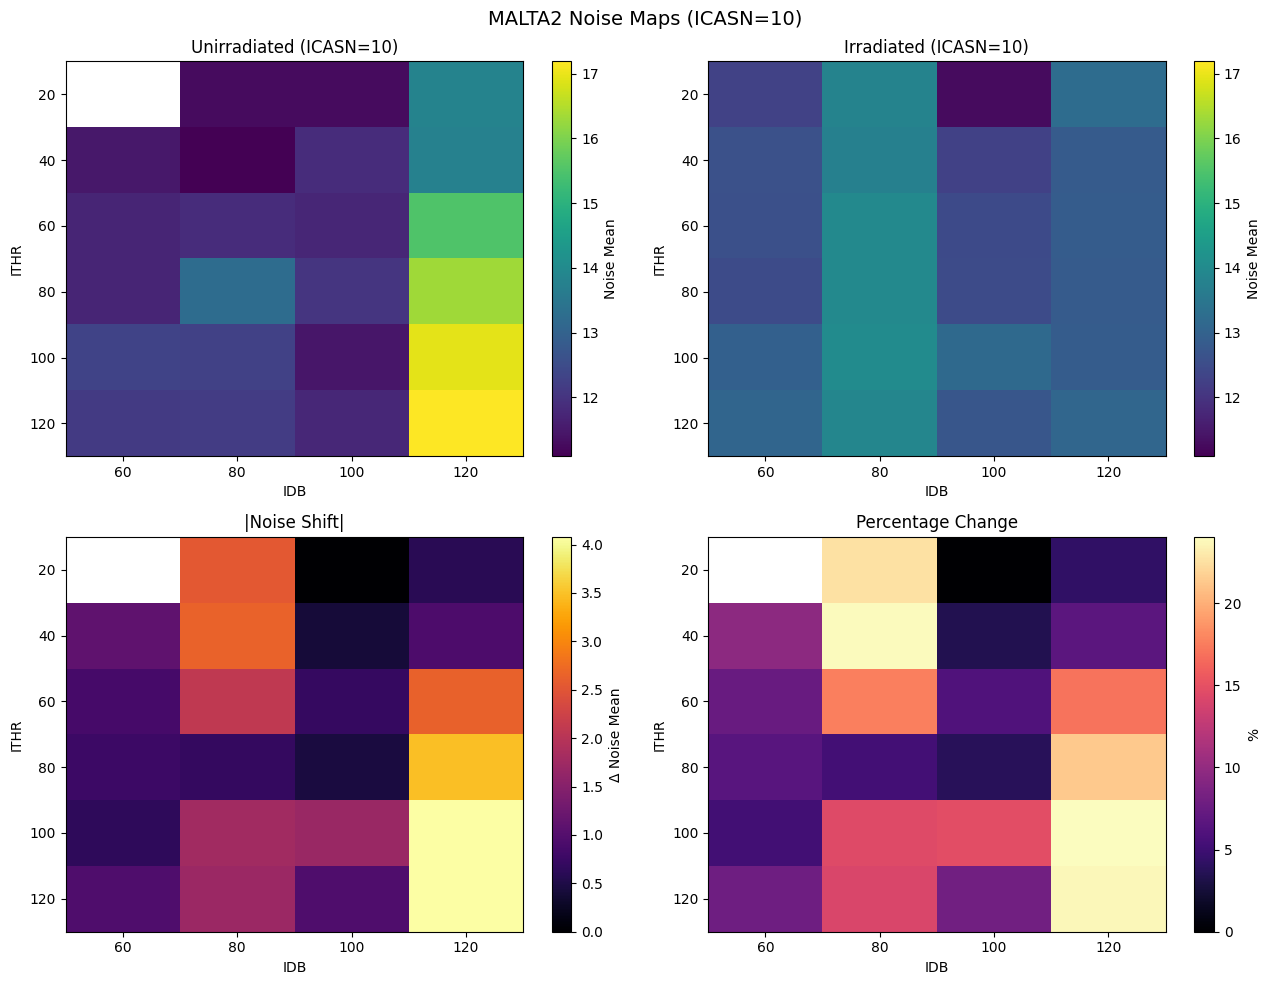

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File paths
file_irrad = "iitm_MALTA2testing-threshold_noise_irrediated.csv"
file_unirrad = "iitm_MALTA2testing-threshold_noise_unirrediated.csv"

# -------- Load data --------
df_irrad = pd.read_csv(file_irrad, na_values=['m',' ','Nan','nan'])
df_unirrad = pd.read_csv(file_unirrad, na_values=['m',' ','Nan','nan'])

df_irrad = df_irrad.dropna(how='all')
df_unirrad = df_unirrad.dropna(how='all')

cols = ["ITHR","IDB","ICASN","NOISE_MEAN", "NOISE_SD"]
df_irrad = df_irrad[cols]
df_unirrad = df_unirrad[cols]

df_irrad = df_irrad.dropna(subset=["NOISE_MEAN"])
df_unirrad = df_unirrad.dropna(subset=["NOISE_MEAN"])

df_unirrad["ITHR"] = pd.to_numeric(df_unirrad["ITHR"], errors='coerce')
df_unirrad["IDB"] = pd.to_numeric(df_unirrad["IDB"], errors='coerce')

df_unirrad = df_unirrad.dropna(subset=["ITHR","IDB"])

icasn_values = sorted(set(df_irrad["ICASN"].unique()) |
                      set(df_unirrad["ICASN"].unique()))

# -------- Loop over ICASN --------
for icasn in icasn_values:

    subset_irrad = df_irrad[df_irrad["ICASN"] == icasn]
    subset_unirrad = df_unirrad[df_unirrad["ICASN"] == icasn]

    if subset_irrad.empty or subset_unirrad.empty:
        continue

    pivot_irrad = subset_irrad.pivot_table(
        index="ITHR", columns="IDB",
        values="NOISE_MEAN", aggfunc="mean"
    ).sort_index().sort_index(axis=1)

    pivot_unirrad = subset_unirrad.pivot_table(
        index="ITHR", columns="IDB",
        values="NOISE_MEAN", aggfunc="mean"
    ).sort_index().sort_index(axis=1)

    # Align matrices
    pivot_unirrad, pivot_irrad = pivot_unirrad.align(pivot_irrad)

    # -------- Calculations --------
    diff = np.abs(pivot_irrad - pivot_unirrad)
    pct_change = 100 * diff / pivot_unirrad

    # -------- Common color scale --------
    vmin = min(pivot_unirrad.min().min(), pivot_irrad.min().min())
    vmax = max(pivot_unirrad.max().max(), pivot_irrad.max().max())

    diff_vmax = diff.max().max()
    pct_vmax = pct_change.max().max()

    # -------- Plot --------
    fig, axes = plt.subplots(2,2, figsize=(13,10))

    # Unirradiated
    im0 = axes[0,0].imshow(
        pivot_unirrad.values,
        aspect='auto',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax
    )

    axes[0,0].set_title(f"Unirradiated (ICASN={icasn})")
    fig.colorbar(im0, ax=axes[0,0], label="Noise Mean")

    # Irradiated
    im1 = axes[0,1].imshow(
        pivot_irrad.values,
        aspect='auto',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax
    )

    axes[0,1].set_title(f"Irradiated (ICASN={icasn})")
    fig.colorbar(im1, ax=axes[0,1], label="Noise Mean")

    # Difference
    im2 = axes[1,0].imshow(
        diff.values,
        aspect='auto',
        cmap='inferno',
        vmin=0,
        vmax=diff_vmax
    )

    axes[1,0].set_title("|Noise Shift|")
    fig.colorbar(im2, ax=axes[1,0], label="Δ Noise Mean")

    # Percentage change
    im3 = axes[1,1].imshow(
        pct_change.values,
        aspect='auto',
        cmap='magma',
        vmin=0,
        vmax=pct_vmax
    )

    axes[1,1].set_title("Percentage Change")
    fig.colorbar(im3, ax=axes[1,1], label="%")

    # -------- Pixel axes --------
    for ax in axes.flat:

        ax.set_xticks(np.arange(len(pivot_irrad.columns)))
        ax.set_xticklabels(pivot_irrad.columns)

        ax.set_yticks(np.arange(len(pivot_irrad.index)))
        ax.set_yticklabels(pivot_irrad.index)

        ax.set_xlabel("IDB")
        ax.set_ylabel("ITHR")

    plt.suptitle(f"MALTA2 Noise Maps (ICASN={icasn})", fontsize=14)

    plt.tight_layout()
    plt.show()

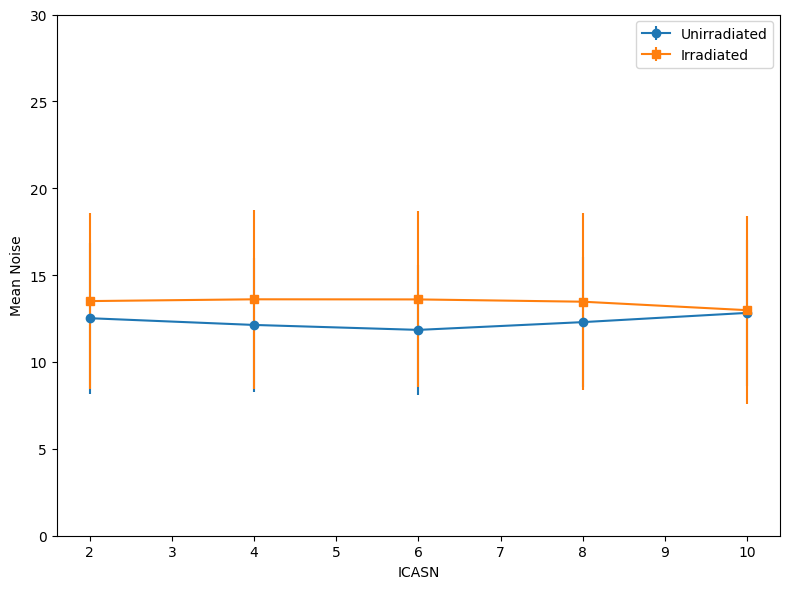

In [5]:
# -------- Noise vs ICASN --------

mean_noise_irrad = df_irrad.groupby("ICASN")["NOISE_MEAN"].mean()
mean_noise_unirrad = df_unirrad.groupby("ICASN")["NOISE_MEAN"].mean()

#std_noise_irrad = df_irrad.groupby("ICASN")["NOISE_MEAN"].std()
#std_noise_unirrad = df_unirrad.groupby("ICASN")["NOISE_MEAN"].std()
std_noise_irrad = df_irrad.groupby("ICASN")["NOISE_SD"].mean()
std_noise_unirrad = df_unirrad.groupby("ICASN")["NOISE_SD"].mean()

icasn_vals = sorted(set(mean_noise_irrad.index) | set(mean_noise_unirrad.index))

plt.figure(figsize=(8,6))

plt.errorbar(
    mean_noise_unirrad.index,
    mean_noise_unirrad.values,
    yerr=std_noise_unirrad.values,
    marker='o',
    label="Unirradiated"
)

plt.errorbar(
    mean_noise_irrad.index,
    mean_noise_irrad.values,
    yerr=std_noise_irrad.values,
    marker='s',
    label="Irradiated"
)

plt.xlabel("ICASN")
plt.ylabel("Mean Noise")
#plt.title("Noise vs ICASN")

plt.ylim(0, 30) 
#plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

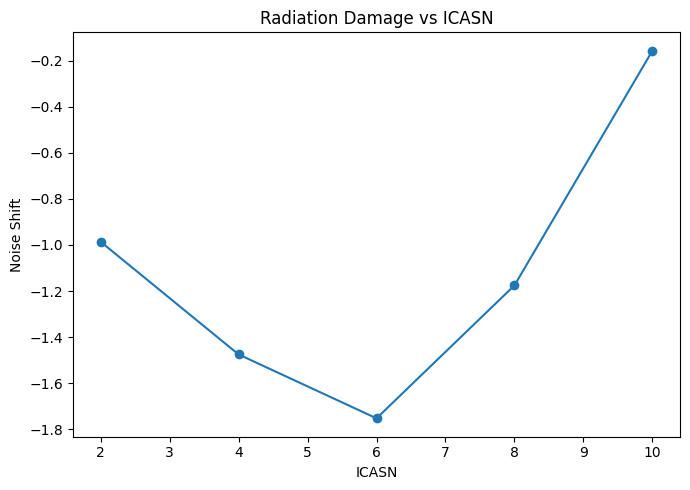

In [6]:
# ---------------------------
# Plot 6: Radiation damage vs ICASN (Noise)
# ---------------------------
#delta = abs(mean_ir - mean_un)
mean_ir = df_irrad.groupby("ICASN")["NOISE_MEAN"].mean()
mean_un = df_unirrad.groupby("ICASN")["NOISE_MEAN"].mean()
delta = mean_un - mean_ir

plt.figure(figsize=(7,5))

plt.plot(delta.index, delta,
         marker='o')

plt.xlabel("ICASN")
plt.ylabel("Noise Shift")
plt.title("Radiation Damage vs ICASN")

#plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ITHR

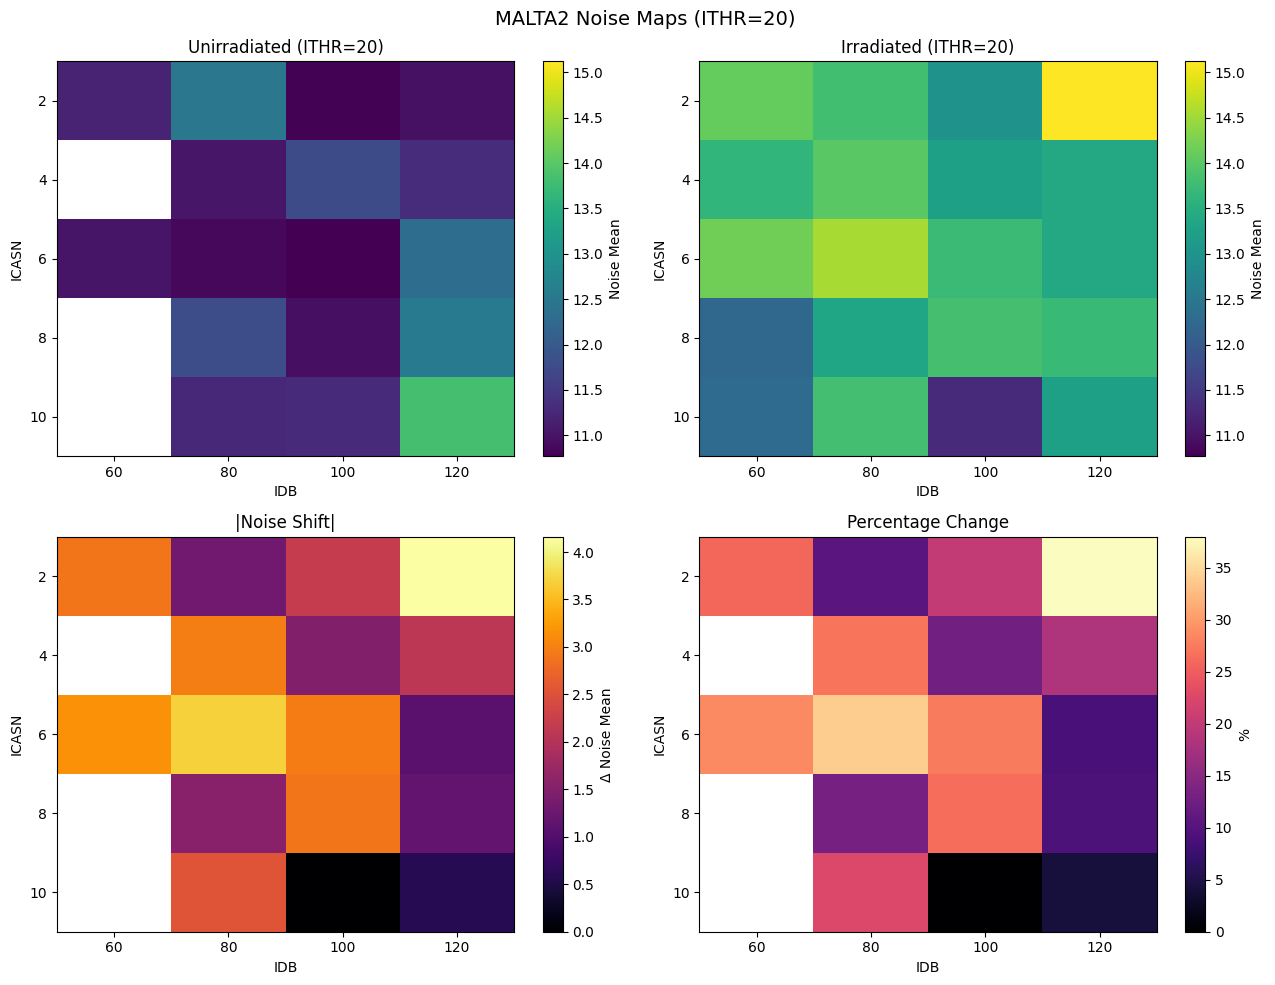

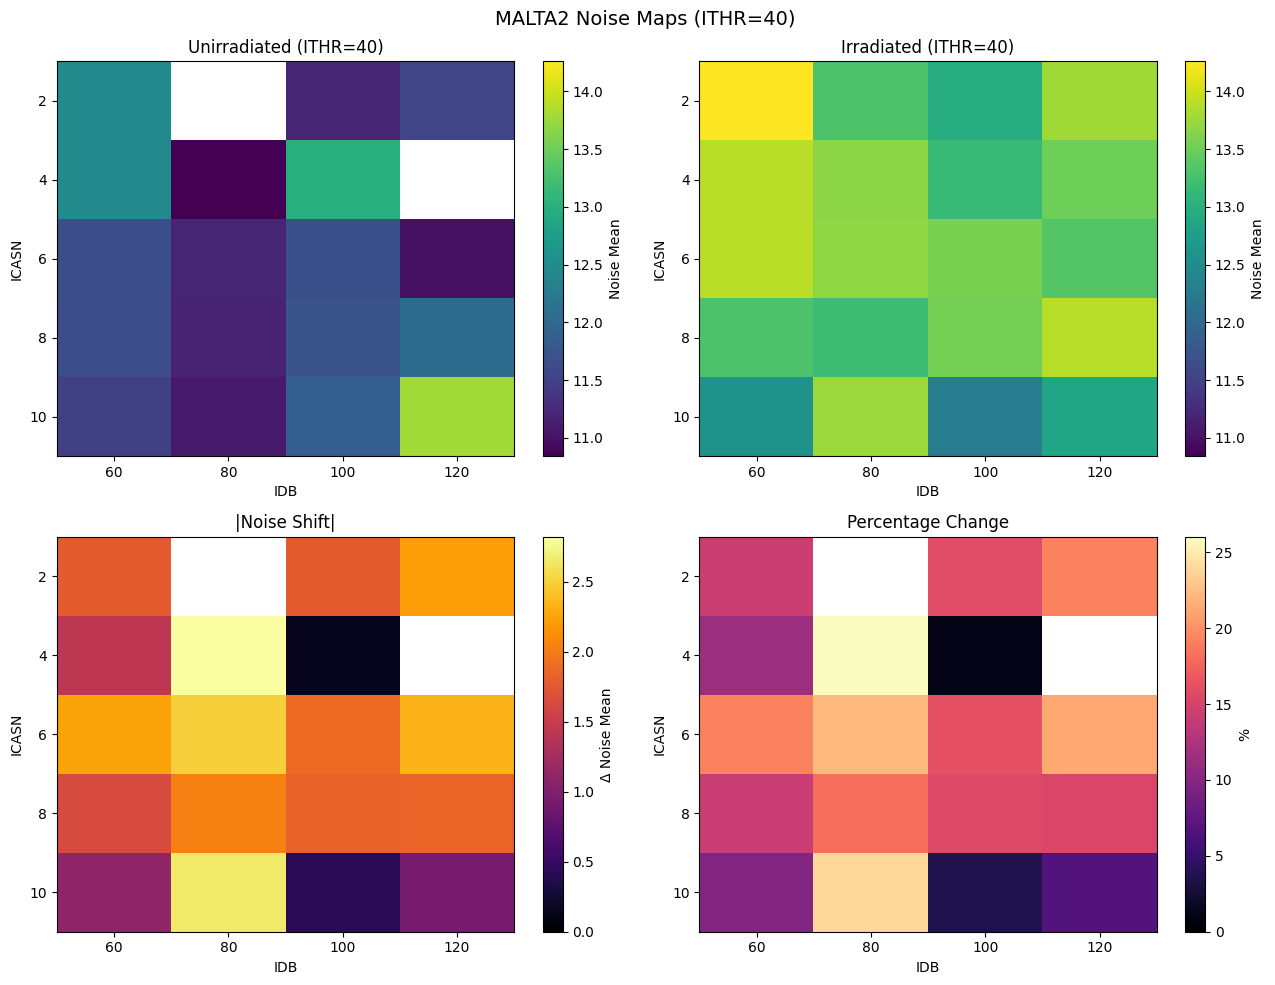

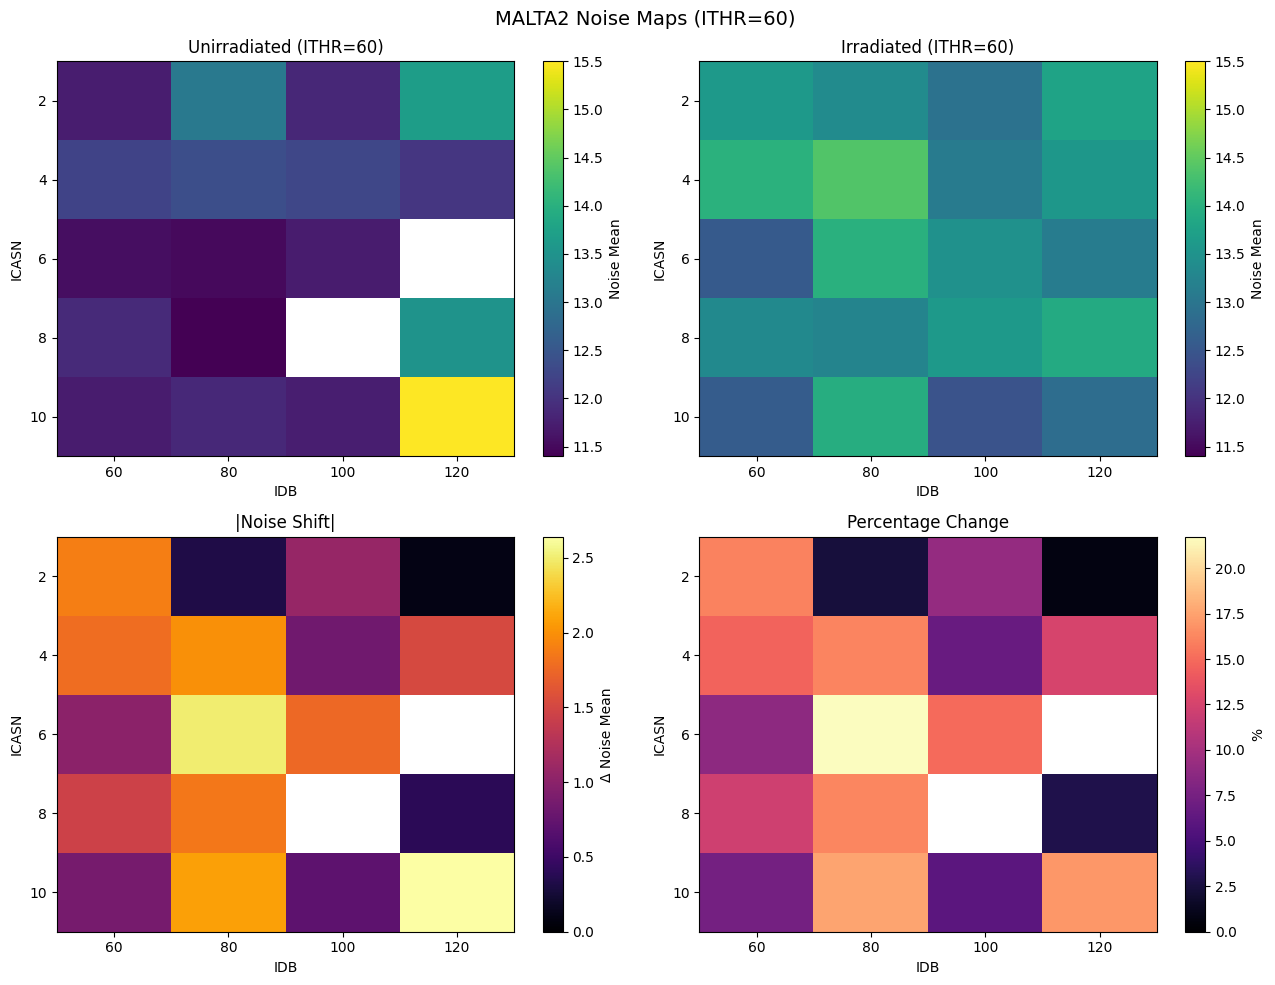

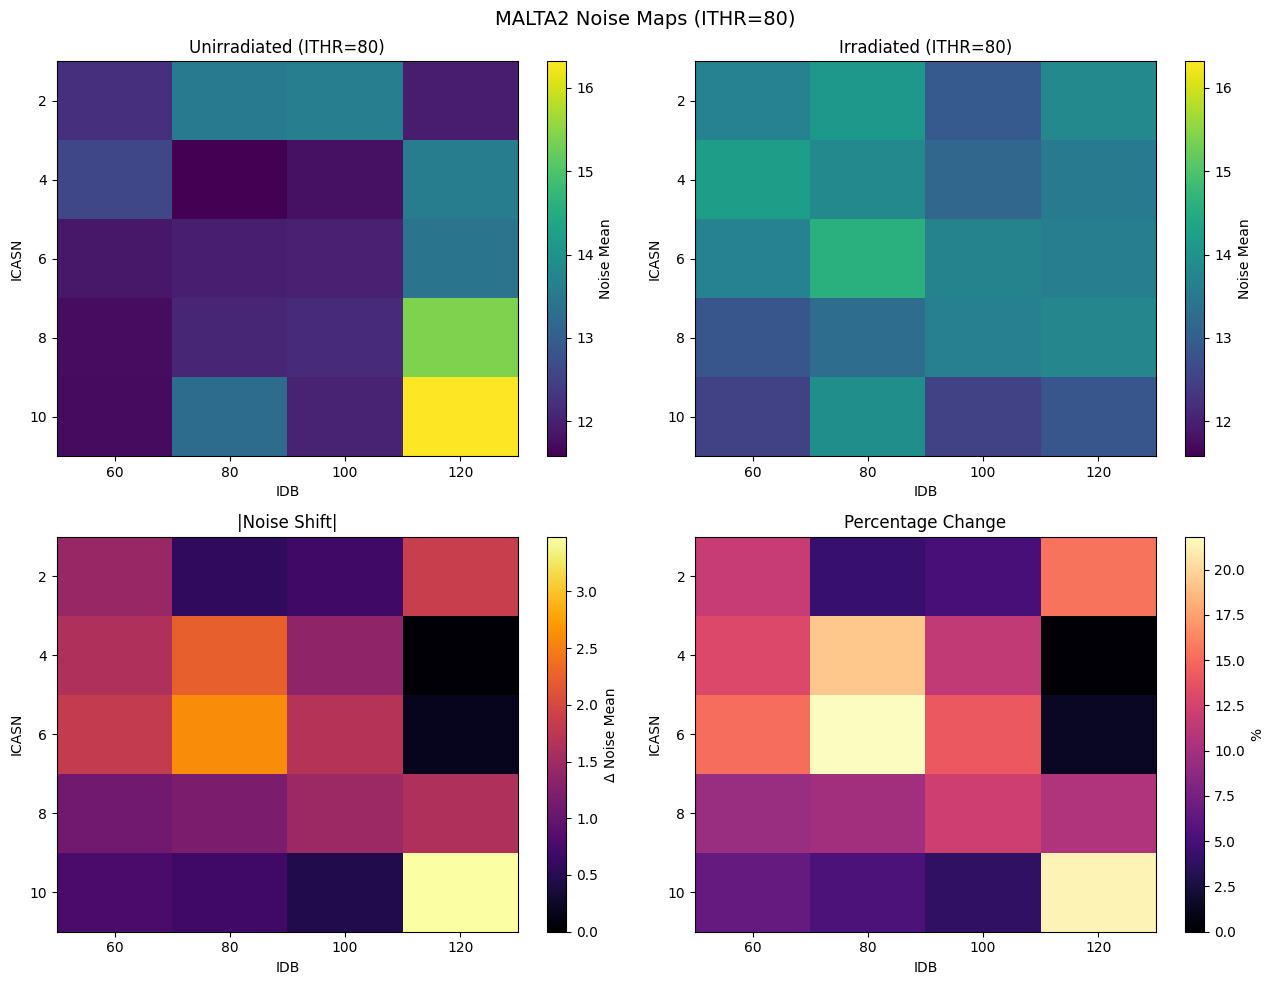

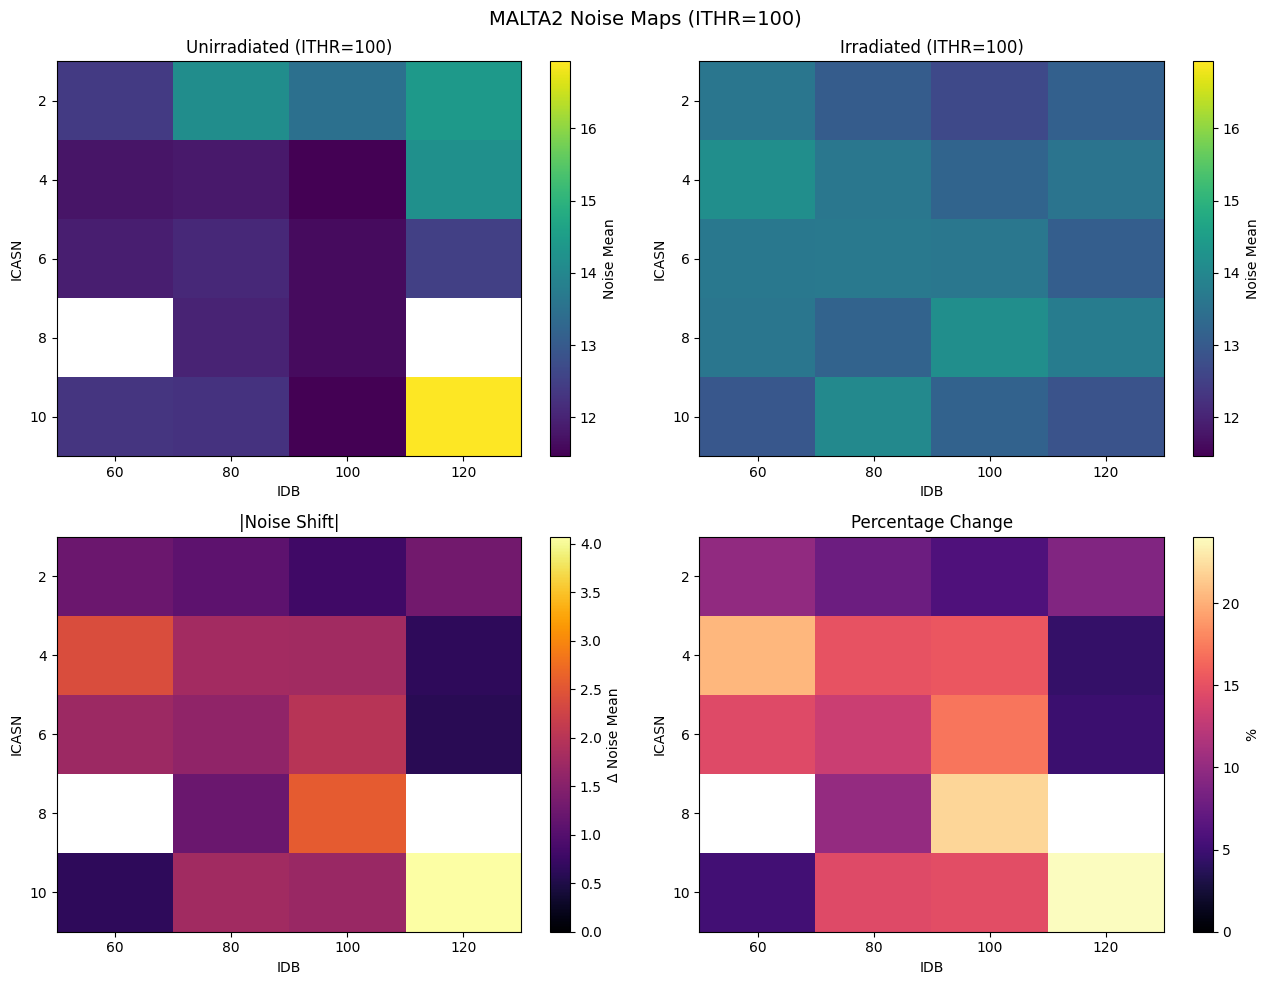

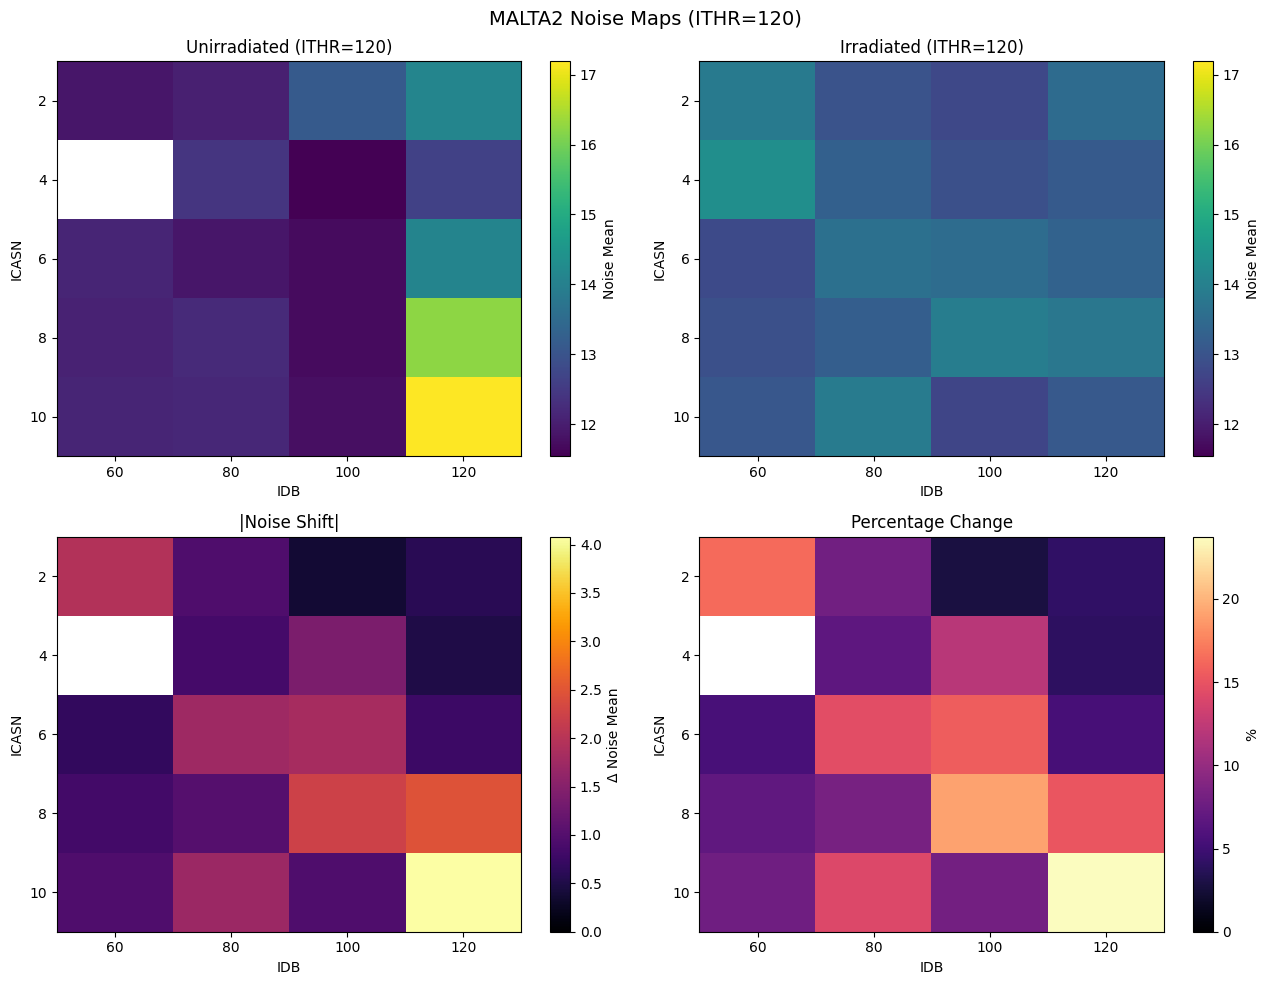

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File paths
file_irrad = "iitm_MALTA2testing-threshold_noise_irrediated.csv"
file_unirrad = "iitm_MALTA2testing-threshold_noise_unirrediated.csv"

# -------- Load data --------
df_irrad = pd.read_csv(file_irrad, na_values=['m',' ','Nan','nan'])
df_unirrad = pd.read_csv(file_unirrad, na_values=['m',' ','Nan','nan'])

df_irrad = df_irrad.dropna(how='all')
df_unirrad = df_unirrad.dropna(how='all')

cols = ["ITHR","IDB","ICASN","NOISE_MEAN","NOISE_SD"]
df_irrad = df_irrad[cols]
df_unirrad = df_unirrad[cols]

df_irrad = df_irrad.dropna(subset=["NOISE_MEAN"])
df_unirrad = df_unirrad.dropna(subset=["NOISE_MEAN"])

df_unirrad["ITHR"] = pd.to_numeric(df_unirrad["ITHR"], errors='coerce')
df_unirrad["IDB"] = pd.to_numeric(df_unirrad["IDB"], errors='coerce')

df_unirrad = df_unirrad.dropna(subset=["ITHR","IDB"])

# -------- Unique ITHR values --------
ithr_values = sorted(set(df_irrad["ITHR"].unique()) |
                     set(df_unirrad["ITHR"].unique()))

# -------- Loop over ITHR --------
for ithr in ithr_values:

    subset_irrad = df_irrad[df_irrad["ITHR"] == ithr]
    subset_unirrad = df_unirrad[df_unirrad["ITHR"] == ithr]

    if subset_irrad.empty or subset_unirrad.empty:
        continue

    pivot_irrad = subset_irrad.pivot_table(
        index="ICASN", columns="IDB",
        values="NOISE_MEAN", aggfunc="mean"
    ).sort_index().sort_index(axis=1)

    pivot_unirrad = subset_unirrad.pivot_table(
        index="ICASN", columns="IDB",
        values="NOISE_MEAN", aggfunc="mean"
    ).sort_index().sort_index(axis=1)

    # Align matrices
    pivot_unirrad, pivot_irrad = pivot_unirrad.align(pivot_irrad)

    # -------- Calculations --------
    diff = np.abs(pivot_irrad - pivot_unirrad)
    pct_change = 100 * diff / pivot_unirrad

    # -------- Common color scale --------
    vmin = min(pivot_unirrad.min().min(), pivot_irrad.min().min())
    vmax = max(pivot_unirrad.max().max(), pivot_irrad.max().max())

    diff_vmax = diff.max().max()
    pct_vmax = pct_change.max().max()

    # -------- Plot --------
    fig, axes = plt.subplots(2,2, figsize=(13,10))

    # Unirradiated
    im0 = axes[0,0].imshow(
        pivot_unirrad.values,
        aspect='auto',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax
    )

    axes[0,0].set_title(f"Unirradiated (ITHR={ithr})")
    fig.colorbar(im0, ax=axes[0,0], label="Noise Mean")

    # Irradiated
    im1 = axes[0,1].imshow(
        pivot_irrad.values,
        aspect='auto',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax
    )

    axes[0,1].set_title(f"Irradiated (ITHR={ithr})")
    fig.colorbar(im1, ax=axes[0,1], label="Noise Mean")

    # Difference
    im2 = axes[1,0].imshow(
        diff.values,
        aspect='auto',
        cmap='inferno',
        vmin=0,
        vmax=diff_vmax
    )

    axes[1,0].set_title("|Noise Shift|")
    fig.colorbar(im2, ax=axes[1,0], label="Δ Noise Mean")

    # Percentage
    im3 = axes[1,1].imshow(
        pct_change.values,
        aspect='auto',
        cmap='magma',
        vmin=0,
        vmax=pct_vmax
    )

    axes[1,1].set_title("Percentage Change")
    fig.colorbar(im3, ax=axes[1,1], label="%")

    # -------- Axes labels --------
    for ax in axes.flat:

        ax.set_xticks(np.arange(len(pivot_irrad.columns)))
        ax.set_xticklabels(pivot_irrad.columns)

        ax.set_yticks(np.arange(len(pivot_irrad.index)))
        ax.set_yticklabels(pivot_irrad.index)

        ax.set_xlabel("IDB")
        ax.set_ylabel("ICASN")

    plt.suptitle(f"MALTA2 Noise Maps (ITHR={ithr})", fontsize=14)

    plt.tight_layout()
    plt.show()

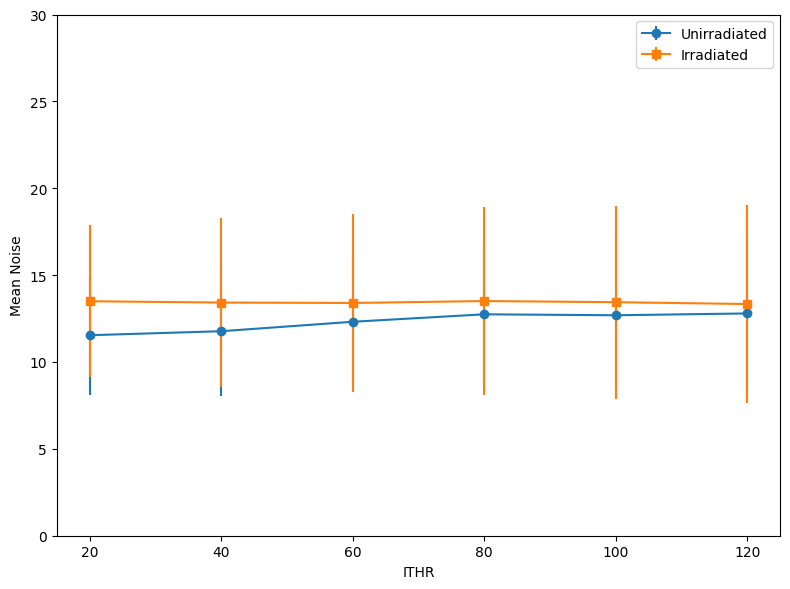

In [10]:
# -------- Noise vs ITHR --------

mean_noise_irrad = df_irrad.groupby("ITHR")["NOISE_MEAN"].mean()
mean_noise_unirrad = df_unirrad.groupby("ITHR")["NOISE_MEAN"].mean()

# Use NOISE_SD directly from CSV
std_noise_irrad = df_irrad.groupby("ITHR")["NOISE_SD"].mean()
std_noise_unirrad = df_unirrad.groupby("ITHR")["NOISE_SD"].mean()

ithr_vals = sorted(set(mean_noise_irrad.index) | set(mean_noise_unirrad.index))

plt.figure(figsize=(8,6))

plt.errorbar(
    mean_noise_unirrad.index,
    mean_noise_unirrad.values,
    yerr=std_noise_unirrad.values,
    marker='o',
    label="Unirradiated"
)

plt.errorbar(
    mean_noise_irrad.index,
    mean_noise_irrad.values,
    yerr=std_noise_irrad.values,
    marker='s',
    label="Irradiated"
)

plt.xlabel("ITHR")
plt.ylabel("Mean Noise")

plt.ylim(0, 30)

plt.legend()

plt.tight_layout()
plt.show()

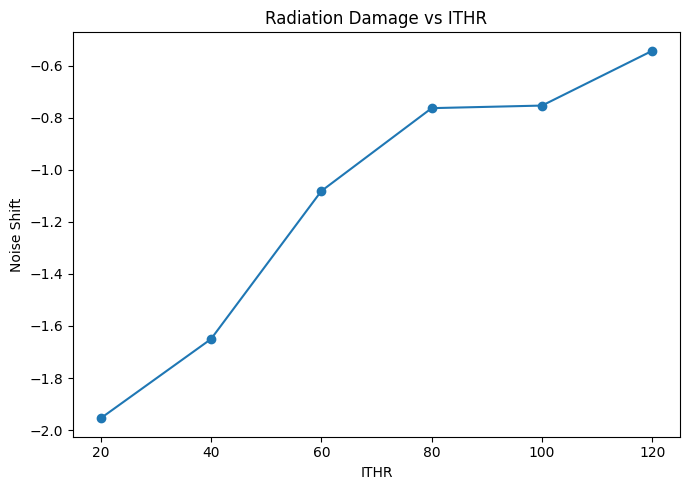

In [11]:
# ---------------------------
# Radiation damage vs ITHR
# ---------------------------

mean_ir = df_irrad.groupby("ITHR")["NOISE_MEAN"].mean()
mean_un = df_unirrad.groupby("ITHR")["NOISE_MEAN"].mean()

delta = mean_un - mean_ir

plt.figure(figsize=(7,5))

plt.plot(delta.index, delta,
         marker='o')

plt.xlabel("ITHR")
plt.ylabel("Noise Shift")
plt.title("Radiation Damage vs ITHR")

plt.tight_layout()
plt.show()

# IDB

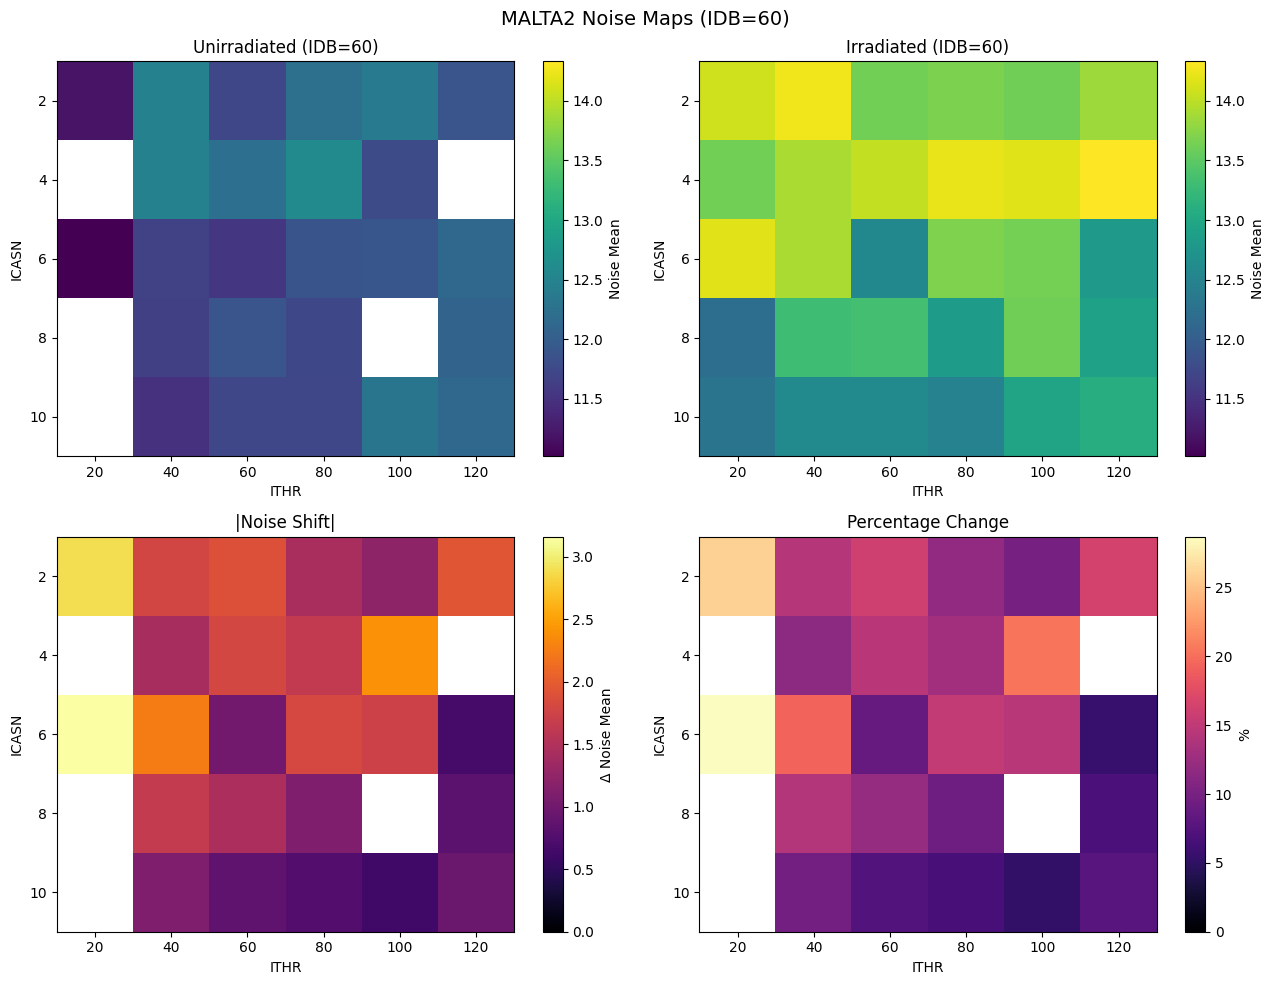

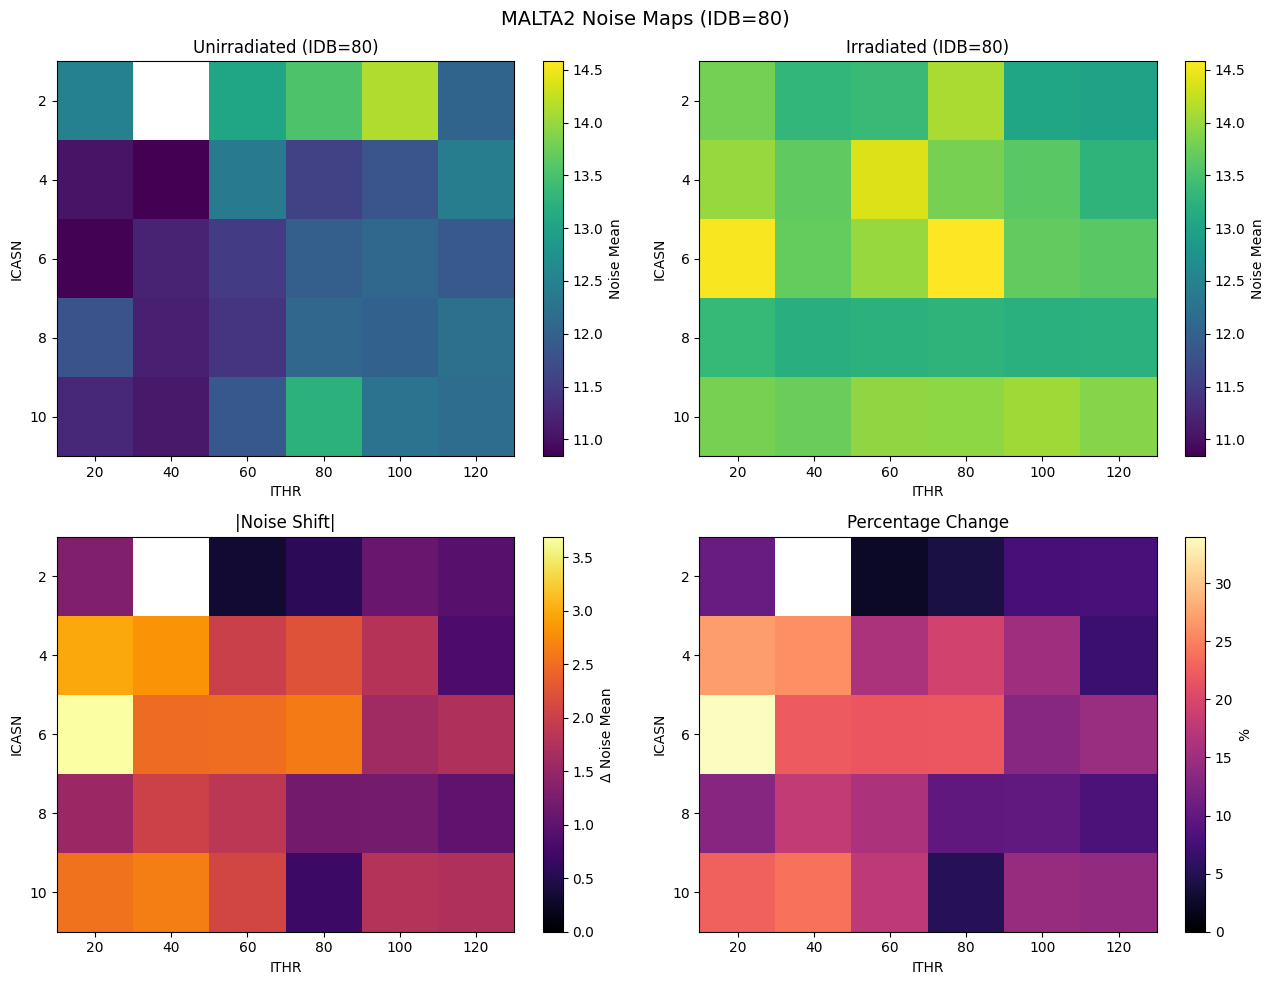

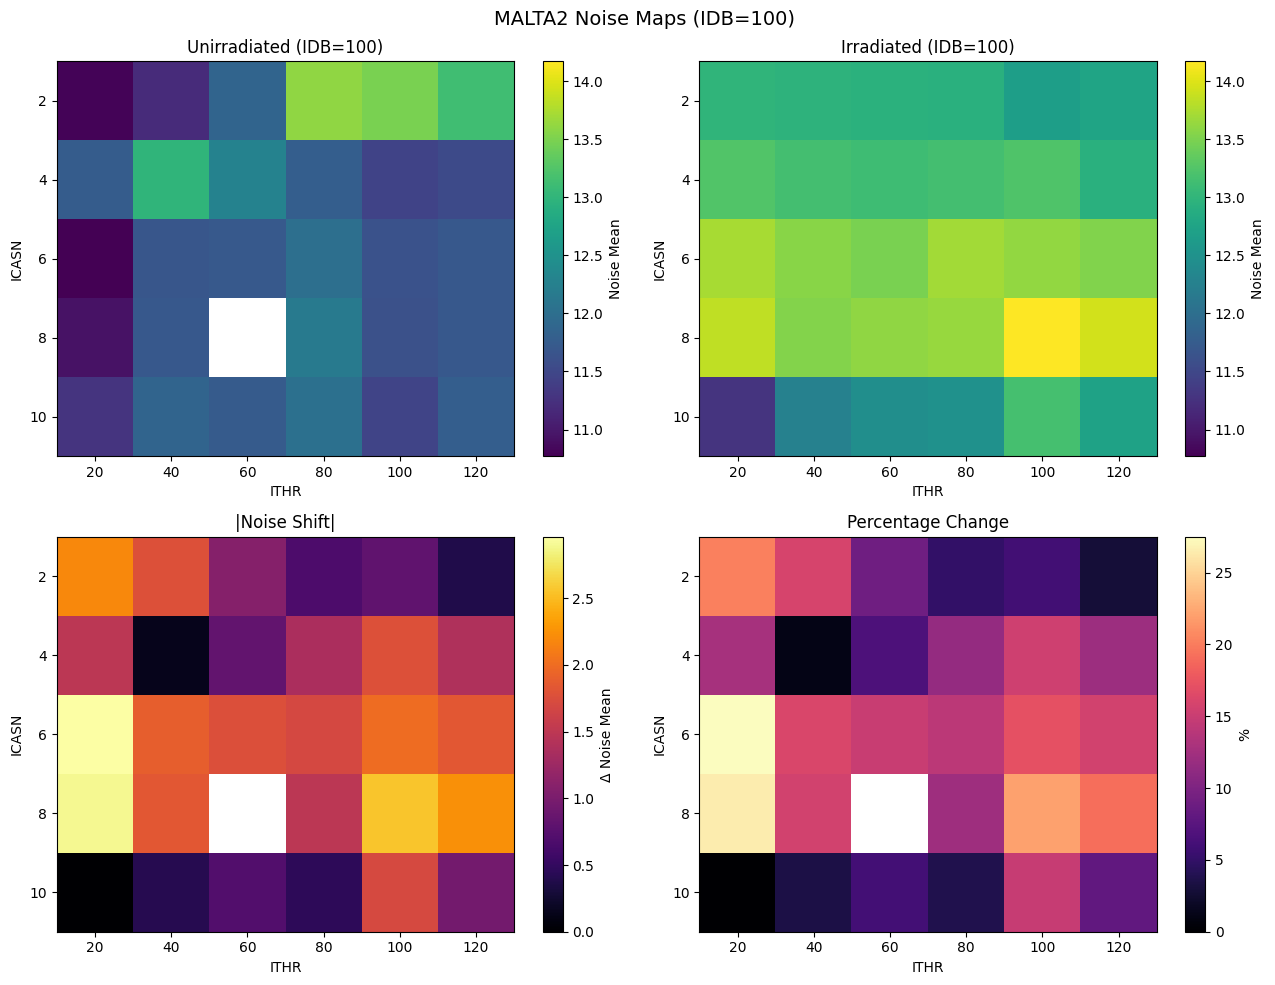

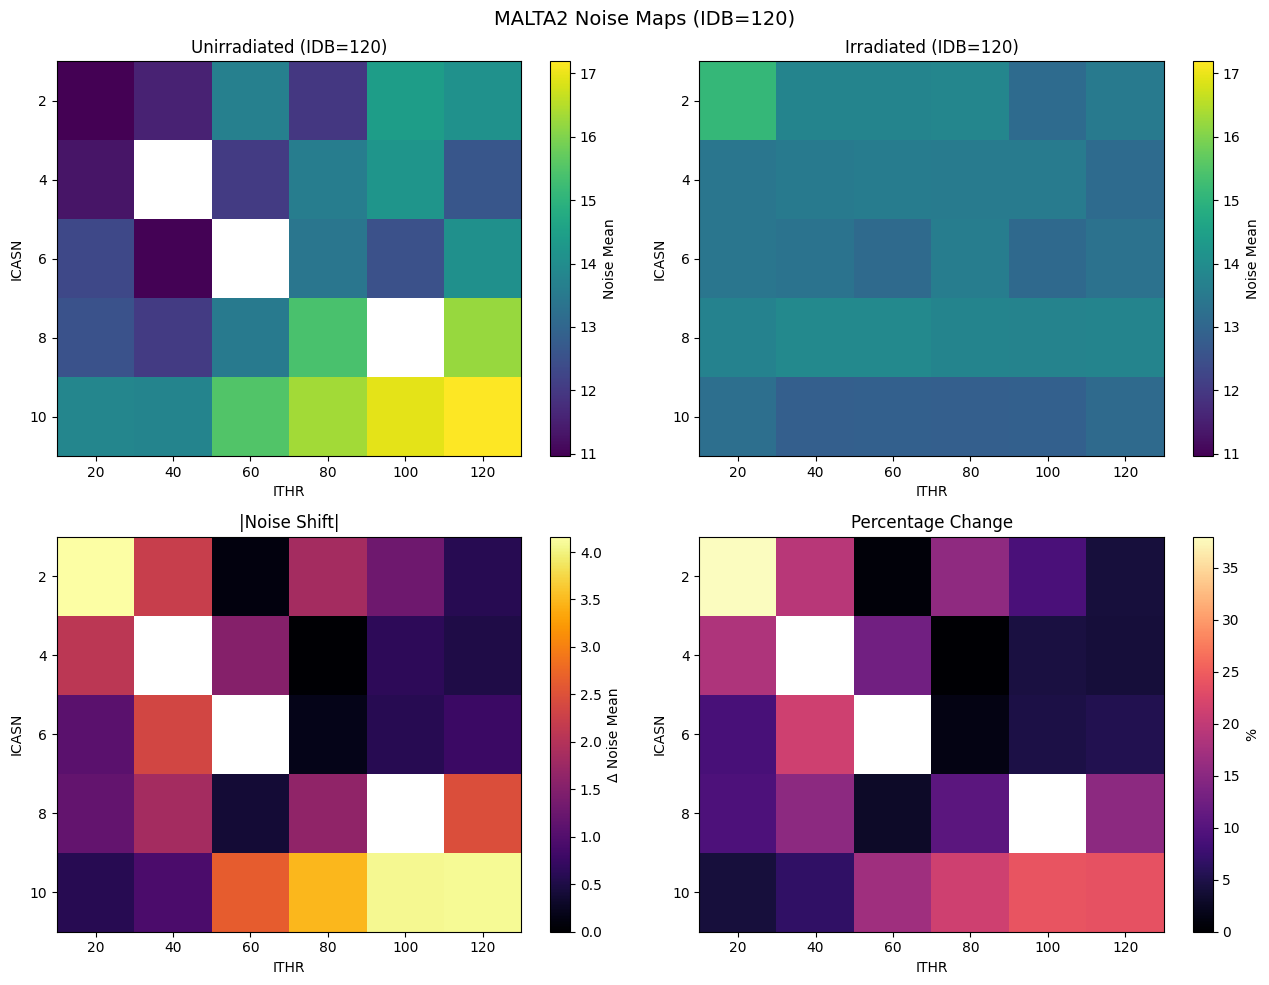

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# File paths
file_irrad = "iitm_MALTA2testing-threshold_noise_irrediated.csv"
file_unirrad = "iitm_MALTA2testing-threshold_noise_unirrediated.csv"

# -------- Load data --------
df_irrad = pd.read_csv(file_irrad, na_values=['m',' ','Nan','nan'])
df_unirrad = pd.read_csv(file_unirrad, na_values=['m',' ','Nan','nan'])

df_irrad = df_irrad.dropna(how='all')
df_unirrad = df_unirrad.dropna(how='all')

cols = ["ITHR","IDB","ICASN","NOISE_MEAN","NOISE_SD"]
df_irrad = df_irrad[cols]
df_unirrad = df_unirrad[cols]

df_irrad = df_irrad.dropna(subset=["NOISE_MEAN"])
df_unirrad = df_unirrad.dropna(subset=["NOISE_MEAN"])

df_unirrad["ITHR"] = pd.to_numeric(df_unirrad["ITHR"], errors='coerce')
df_unirrad["IDB"] = pd.to_numeric(df_unirrad["IDB"], errors='coerce')

df_unirrad = df_unirrad.dropna(subset=["ITHR","IDB"])

# -------- Unique IDB values --------
idb_values = sorted(set(df_irrad["IDB"].unique()) |
                    set(df_unirrad["IDB"].unique()))

# -------- Loop over IDB --------
for idb in idb_values:

    subset_irrad = df_irrad[df_irrad["IDB"] == idb]
    subset_unirrad = df_unirrad[df_unirrad["IDB"] == idb]

    if subset_irrad.empty or subset_unirrad.empty:
        continue

    # Pivot tables (ICASN vs ITHR)
    pivot_irrad = subset_irrad.pivot_table(
        index="ICASN", columns="ITHR",
        values="NOISE_MEAN", aggfunc="mean"
    ).sort_index().sort_index(axis=1)

    pivot_unirrad = subset_unirrad.pivot_table(
        index="ICASN", columns="ITHR",
        values="NOISE_MEAN", aggfunc="mean"
    ).sort_index().sort_index(axis=1)

    # Align matrices
    pivot_unirrad, pivot_irrad = pivot_unirrad.align(pivot_irrad)

    # -------- Calculations --------
    diff = np.abs(pivot_irrad - pivot_unirrad)
    pct_change = 100 * diff / pivot_unirrad

    # -------- Common color scale --------
    vmin = min(pivot_unirrad.min().min(), pivot_irrad.min().min())
    vmax = max(pivot_unirrad.max().max(), pivot_irrad.max().max())

    diff_vmax = diff.max().max()
    pct_vmax = pct_change.max().max()

    # -------- Plot --------
    fig, axes = plt.subplots(2,2, figsize=(13,10))

    # Unirradiated
    im0 = axes[0,0].imshow(
        pivot_unirrad.values,
        aspect='auto',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax
    )
    axes[0,0].set_title(f"Unirradiated (IDB={idb})")
    fig.colorbar(im0, ax=axes[0,0], label="Noise Mean")

    # Irradiated
    im1 = axes[0,1].imshow(
        pivot_irrad.values,
        aspect='auto',
        cmap='viridis',
        vmin=vmin,
        vmax=vmax
    )
    axes[0,1].set_title(f"Irradiated (IDB={idb})")
    fig.colorbar(im1, ax=axes[0,1], label="Noise Mean")

    # Difference
    im2 = axes[1,0].imshow(
        diff.values,
        aspect='auto',
        cmap='inferno',
        vmin=0,
        vmax=diff_vmax
    )
    axes[1,0].set_title("|Noise Shift|")
    fig.colorbar(im2, ax=axes[1,0], label="Δ Noise Mean")

    # Percentage
    im3 = axes[1,1].imshow(
        pct_change.values,
        aspect='auto',
        cmap='magma',
        vmin=0,
        vmax=pct_vmax
    )
    axes[1,1].set_title("Percentage Change")
    fig.colorbar(im3, ax=axes[1,1], label="%")

    # -------- Axes labels --------
    for ax in axes.flat:

        ax.set_xticks(np.arange(len(pivot_irrad.columns)))
        ax.set_xticklabels(pivot_irrad.columns)

        ax.set_yticks(np.arange(len(pivot_irrad.index)))
        ax.set_yticklabels(pivot_irrad.index)

        ax.set_xlabel("ITHR")
        ax.set_ylabel("ICASN")

    plt.suptitle(f"MALTA2 Noise Maps (IDB={idb})", fontsize=14)

    plt.tight_layout()
    plt.show()

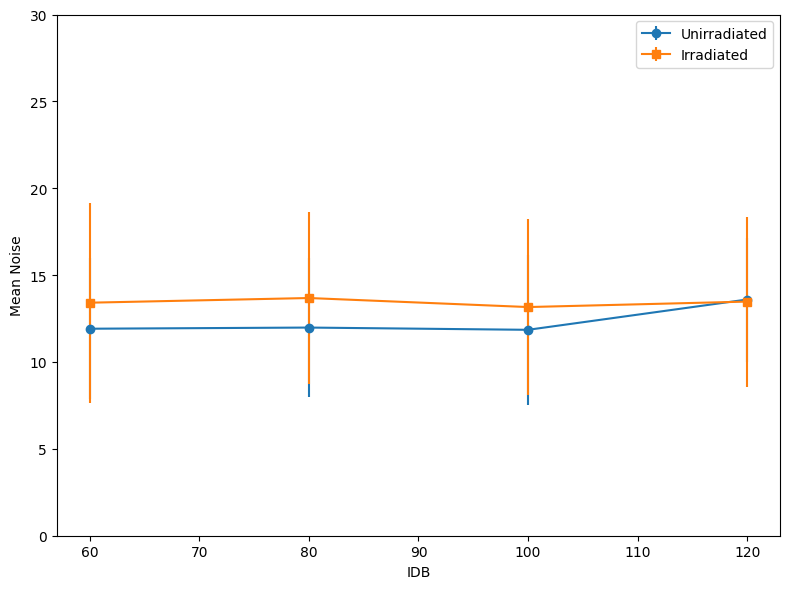

In [14]:
# -------- Noise vs IDB --------

mean_noise_irrad = df_irrad.groupby("IDB")["NOISE_MEAN"].mean()
mean_noise_unirrad = df_unirrad.groupby("IDB")["NOISE_MEAN"].mean()

# Use NOISE_SD directly from CSV
std_noise_irrad = df_irrad.groupby("IDB")["NOISE_SD"].mean()
std_noise_unirrad = df_unirrad.groupby("IDB")["NOISE_SD"].mean()

idb_vals = sorted(set(mean_noise_irrad.index) | set(mean_noise_unirrad.index))

plt.figure(figsize=(8,6))

plt.errorbar(
    mean_noise_unirrad.index,
    mean_noise_unirrad.values,
    yerr=std_noise_unirrad.values,
    marker='o',
    label="Unirradiated"
)

plt.errorbar(
    mean_noise_irrad.index,
    mean_noise_irrad.values,
    yerr=std_noise_irrad.values,
    marker='s',
    label="Irradiated"
)

plt.xlabel("IDB")
plt.ylabel("Mean Noise")

plt.ylim(0, 30)

plt.legend()

plt.tight_layout()
plt.show()

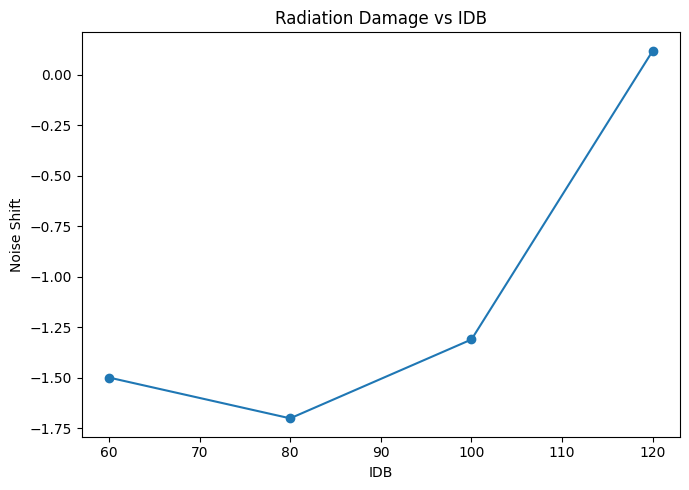

In [15]:
# ---------------------------
# Radiation damage vs IDB
# ---------------------------

mean_ir = df_irrad.groupby("IDB")["NOISE_MEAN"].mean()
mean_un = df_unirrad.groupby("IDB")["NOISE_MEAN"].mean()

delta = mean_un - mean_ir

plt.figure(figsize=(7,5))

plt.plot(delta.index, delta, marker='o')

plt.xlabel("IDB")
plt.ylabel("Noise Shift")
plt.title("Radiation Damage vs IDB")

plt.tight_layout()
plt.show()